In [1]:
import pandas as pd
from pathlib import Path

def load_processed_tables(
    out_dir: str | Path,
    prefix: str = "tx_shoreline",
    format: str = "parquet",
):
    out_dir = Path(out_dir)

    if format == "parquet":
        shoreline_df = pd.read_parquet(out_dir / f"{prefix}_obs.parquet")
        transects = pd.read_parquet(out_dir / f"{prefix}_transects.parquet")
        stats = pd.read_parquet(out_dir / f"{prefix}_stats.parquet")
    elif format == "csv":
        shoreline_df = pd.read_csv(out_dir / f"{prefix}_obs.csv", parse_dates=["datetime"])
        transects = pd.read_csv(out_dir / f"{prefix}_transects.csv")
        stats = pd.read_csv(out_dir / f"{prefix}_stats.csv")
    else:
        raise ValueError("format must be 'parquet' or 'csv'")

    return shoreline_df, transects, stats

shoreline_df, transects, stats = load_processed_tables(
    "F:/crs/proj/2026_shoreline_analysis/processed",
    prefix="tx_shoreline",
    format="parquet",
)

In [2]:
print(shoreline_df.columns.tolist())
print(shoreline_df[["datetime", "ID", "distance"]].head())
print(shoreline_df.dtypes)

['date', 'time', 'ID', 'transectStart_X_x', 'transectStart_Y_x', 'transectEnd_X_x', 'transectEnd_Y_x', 'distance', 'slope', 'tide', 'shoreline_x', 'shoreline_y', 'datetime', 'year', 't', 'transectStart_X_y', 'transectStart_Y_y', 'transectEnd_X_y', 'transectEnd_Y_y', 'lon_mid', 'lat_mid', 'x_proj', 'y_proj', 'ds_m', 's_m', 's_km', 'coast_order']
             datetime                ID   distance
0 1984-06-23 16:13:17  usa_TX_0001_0001  108.79432
1 1984-09-11 16:14:33  usa_TX_0001_0001   85.88579
2 1984-11-30 16:14:46  usa_TX_0001_0001   70.05994
3 1985-01-01 16:14:42  usa_TX_0001_0001   75.72523
4 1985-03-22 16:15:16  usa_TX_0001_0001   88.70066
date                         object
time                         object
ID                           object
transectStart_X_x           float64
transectStart_Y_x           float64
transectEnd_X_x             float64
transectEnd_Y_x             float64
distance                    float64
slope                       float64
tide                   

In [3]:
import numpy as np
import pandas as pd

def loess_time_window(t_days, y, window_days=90, min_points=5):
    """
    Time-windowed LOWESS using tricube weights.
    """
    t = np.asarray(t_days, dtype=float)
    y = np.asarray(y, dtype=float)

    yhat = np.full_like(y, np.nan, dtype=float)
    npts = np.zeros_like(y, dtype=int)

    for j, t0 in enumerate(t):
        dt = np.abs(t - t0)
        mask = np.isfinite(dt) & np.isfinite(y) & (dt <= window_days)

        if np.sum(mask) < min_points:
            continue

        tj = t[mask]
        yj = y[mask]

        # tricube weights
        w = (1 - (dt[mask] / window_days) ** 3) ** 3

        # weighted linear regression centered at t0
        X = np.vstack([np.ones_like(tj), tj - t0]).T
        WX = X * w[:, None]
        beta = np.linalg.pinv(X.T @ WX) @ (X.T @ (w * yj))

        yhat[j] = beta[0]
        npts[j] = np.sum(mask)

    return yhat, npts


def compute_loess_all_transects(
    df,
    time_col="datetime",
    id_col="ID",
    y_col="distance",
    seasonal_window=111,
    annual_window=4*365,
):
    """
    Compute seasonal and annual LOWESS for each transect.

    Parameters
    ----------
    df : DataFrame
        Observation-level shoreline dataframe
    time_col : str
        Datetime column name
    id_col : str
        Transect ID column name
    y_col : str
        Shoreline position column name
    seasonal_window : float
        Half-window in days for seasonal smoothing
    annual_window : float
        Half-window in days for annual smoothing
    """
    out = []

    for tid, g in df.groupby(id_col):
        g = g.sort_values(time_col).copy()

        # force datetime conversion
        g[time_col] = pd.to_datetime(g[time_col], errors="coerce")

        # drop rows missing time or shoreline value
        g = g.dropna(subset=[time_col, y_col]).copy()

        if len(g) == 0:
            continue

        # numeric time in days since first observation for this transect
        t0 = g[time_col].iloc[0]
        t_days = (g[time_col] - t0).dt.total_seconds() / 86400.0
        y = pd.to_numeric(g[y_col], errors="coerce").to_numpy(dtype=float)

        y_seasonal, n_seas = loess_time_window(
            t_days.to_numpy(),
            y,
            window_days=seasonal_window,
        )

        y_annual, n_ann = loess_time_window(
            t_days.to_numpy(),
            y,
            window_days=annual_window,
        )

        g["y_seasonal"] = y_seasonal
        g["y_annual"] = y_annual
        g["n_seasonal"] = n_seas
        g["n_annual"] = n_ann

        out.append(g)

    if len(out) == 0:
        raise ValueError("No valid transect records found after datetime/value cleaning.")

    return pd.concat(out, ignore_index=True)


In [4]:
def build_time_space_matrix(
    df,
    value_col="y_annual",
    time_col="datetime",
    s_col="s_km",
    freq="30D",
):
    """
    Interpolate irregular transect data onto a common time grid.
    """
    df = df.copy()
    df[time_col] = pd.to_datetime(df[time_col], errors="coerce")
    df = df.dropna(subset=[time_col, s_col, value_col])

    tgrid = pd.date_range(df[time_col].min(), df[time_col].max(), freq=freq)
    transects = np.sort(df[s_col].unique())
    M = np.full((len(tgrid), len(transects)), np.nan)

    tg = (tgrid - tgrid[0]).total_seconds().to_numpy()

    for i, s in enumerate(transects):
        g = df[df[s_col] == s].sort_values(time_col)

        if len(g) < 2:
            continue

        ti = ((g[time_col] - tgrid[0]).dt.total_seconds()).to_numpy()
        yi = pd.to_numeric(g[value_col], errors="coerce").to_numpy(dtype=float)

        good = np.isfinite(ti) & np.isfinite(yi)
        if np.sum(good) < 2:
            continue

        M[:, i] = np.interp(tg, ti[good], yi[good], left=np.nan, right=np.nan)

    return tgrid, transects, M

In [5]:
import matplotlib.pyplot as plt
def plot_heatmap(
    tgrid,
    s,
    M,
    title="",
    cmap="RdBu_r",
    vmin=None,
    vmax=None
):
    """
    Plot time-space heatmap (time downward).
    """

    fig, ax = plt.subplots(figsize=(10, 6))

    im = ax.imshow(
        M,
        aspect="auto",
        extent=[s.min(), s.max(), tgrid[-1], tgrid[0]],
        cmap=cmap,
        vmin=vmin,
        vmax=vmax
    )

    ax.set_xlabel("Alongshore distance (km)")
    ax.set_ylabel("Time")

    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label("Shoreline position (m)")

    ax.set_title(title)

    return fig, ax

In [6]:
def plot_transect_timeseries_two_panel(
    df,
    transect_id,
    time_col="datetime",
    y_col="distance",
    id_col="ID",
):
    g = df.copy()

    g[id_col] = g[id_col].astype(str).str.strip()
    transect_id = str(transect_id).strip()

    g[time_col] = pd.to_datetime(g[time_col], errors="coerce")
    for col in [y_col, "y_seasonal", "y_annual"]:
        g[col] = pd.to_numeric(g[col], errors="coerce")

    g = g[g[id_col] == transect_id].sort_values(time_col).copy()

    if len(g) == 0:
        raise ValueError(f"No rows found where {id_col} == {transect_id}")

    g["seasonal_anomaly"] = g["y_seasonal"] - g["y_annual"]
    g["raw_minus_annual"] = g[y_col] - g["y_annual"]

    fig, axs = plt.subplots(
        2, 1,
        figsize=(10, 6),
        sharex=True,
        gridspec_kw={"height_ratios": [2, 1]}
    )

    axs[0].plot(g[time_col], g[y_col], ".", label="raw", alpha=0.4)
    axs[0].plot(g[time_col], g["y_seasonal"], "-", c="tab:orange", lw=2, label="seasonal")
    axs[0].plot(g[time_col], g["y_annual"], "-", c="tab:red", lw=3, label="annual")
    axs[0].set_ylabel("Shoreline position (m)")
    axs[0].set_title(f"Transect {transect_id}")
    axs[0].legend()

    axs[1].plot(g[time_col], g["raw_minus_annual"], ".", alpha=0.35, label="raw - annual")
    axs[1].plot(g[time_col], g["seasonal_anomaly"], "-", c="tab:orange", lw=2, label="seasonal - annual")
    axs[1].axhline(0.0, linestyle="--", lw=1)
    axs[1].set_xlabel("Time")
    axs[1].set_ylabel("Anomaly (m)")
    axs[1].legend()

    fig.tight_layout()
    return fig, axs

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def plot_mean_annual_cycle(
    df,
    transect_id,
    time_col="datetime",
    id_col="ID",
    seasonal_col="y_seasonal",
    annual_col="y_annual",
    ndoy=366,
    min_points_per_year=6,
    figsize=(10, 4),
):
    """
    Plot stacked annual seasonal cycles for one transect.

    The cycle is defined as:
        seasonal_anomaly = y_seasonal - y_annual

    For each year, the anomaly is interpolated onto a common day-of-year grid.
    All yearly curves are plotted in faint gray.
    The mean annual cycle is plotted in orange, with +/- 1 std shaded.

    Parameters
    ----------
    df : DataFrame
        Observation-level dataframe containing datetime, ID, y_seasonal, y_annual
    transect_id : str
        Transect identifier value
    time_col, id_col : str
        Column names
    seasonal_col, annual_col : str
        Names of seasonal and annual LOWESS columns
    ndoy : int
        Number of day-of-year grid points (usually 366)
    min_points_per_year : int
        Minimum number of valid points required in a year to include it
    """

    g = df.copy()

    g[id_col] = g[id_col].astype(str).str.strip()
    transect_id = str(transect_id).strip()

    g[time_col] = pd.to_datetime(g[time_col], errors="coerce")
    g[seasonal_col] = pd.to_numeric(g[seasonal_col], errors="coerce")
    g[annual_col] = pd.to_numeric(g[annual_col], errors="coerce")

    g = g[g[id_col] == transect_id].sort_values(time_col).copy()

    if len(g) == 0:
        raise ValueError(f"No rows found where {id_col} == {transect_id}")

    g = g.dropna(subset=[time_col, seasonal_col, annual_col]).copy()
    if len(g) == 0:
        raise ValueError("No valid rows remain after dropping NaNs in time/LOWESS columns.")

    g["seasonal_anomaly"] = g[seasonal_col] - g[annual_col]
    g["year"] = g[time_col].dt.year

    # fractional day-of-year
    g["doy"] = (
        g[time_col].dt.dayofyear
        + g[time_col].dt.hour / 24.0
        + g[time_col].dt.minute / 1440.0
        + g[time_col].dt.second / 86400.0
    )

    # common within-year grid
    doy_grid = np.linspace(1, 366, ndoy)

    curves = []
    years_used = []

    for yr, gy in g.groupby("year"):
        gy = gy.sort_values("doy").copy()

        x = gy["doy"].to_numpy(dtype=float)
        y = gy["seasonal_anomaly"].to_numpy(dtype=float)

        good = np.isfinite(x) & np.isfinite(y)
        x = x[good]
        y = y[good]

        if len(x) < min_points_per_year:
            continue

        # collapse duplicate doy values if present
        tmp = pd.DataFrame({"doy": x, "y": y}).groupby("doy", as_index=False).mean()
        x = tmp["doy"].to_numpy(dtype=float)
        y = tmp["y"].to_numpy(dtype=float)

        if len(x) < 2:
            continue

        # interpolate only inside the range for that year
        yi = np.interp(doy_grid, x, y, left=np.nan, right=np.nan)
        inside = (doy_grid >= np.nanmin(x)) & (doy_grid <= np.nanmax(x))
        yi[~inside] = np.nan

        curves.append(yi)
        years_used.append(yr)

    if len(curves) == 0:
        raise ValueError("No years had enough valid points to build annual cycles.")

    Y = np.vstack(curves)  # (nyear, ndoy)

    mean_cycle = np.nanmean(Y, axis=0)
    std_cycle = np.nanstd(Y, axis=0, ddof=1) if Y.shape[0] > 1 else np.full(ndoy, np.nan)

    fig, ax = plt.subplots(figsize=figsize)

    # all yearly curves in faint gray
    for i in range(Y.shape[0]):
        ax.plot(doy_grid, Y[i, :], "-", color="0.7", alpha=0.4, lw=1)

    # std shading
    ax.fill_between(
        doy_grid,
        mean_cycle - std_cycle,
        mean_cycle + std_cycle,
        color="orange",
        alpha=0.25,
        label="±1 std. dev."
    )

    # mean annual cycle
    ax.plot(
        doy_grid,
        mean_cycle,
        "-",
        color="orange",
        lw=2.5,
        label="Mean annual cycle"
    )

    ax.axhline(0.0, color="0.4", ls="--", lw=1)

    ax.set_xlabel("Day of year")
    ax.set_ylabel("Seasonal anomaly (m)")
    ax.set_title(f"Transect {transect_id}: mean annual cycle")
    ax.legend()

    fig.tight_layout()

    return fig, ax, {
        "doy_grid": doy_grid,
        "annual_curves": Y,
        "years_used": np.array(years_used),
        "mean_cycle": mean_cycle,
        "std_cycle": std_cycle,
    }

In [8]:
df_loess = compute_loess_all_transects(
    shoreline_df,
    time_col="datetime",
    id_col="ID",
    y_col="distance",
)

# Compute LOWESS
df_loess = compute_loess_all_transects(shoreline_df)

In [9]:
# Step 2: build matrices
tgrid, s, M_seasonal = build_time_space_matrix(df_loess, "y_seasonal")
_, _, M_annual = build_time_space_matrix(df_loess, "y_annual")

(<Figure size 1000x600 with 2 Axes>,
 <Axes: title={'center': 'Annual LOWESS'}, xlabel='Alongshore distance (km)', ylabel='Time'>)

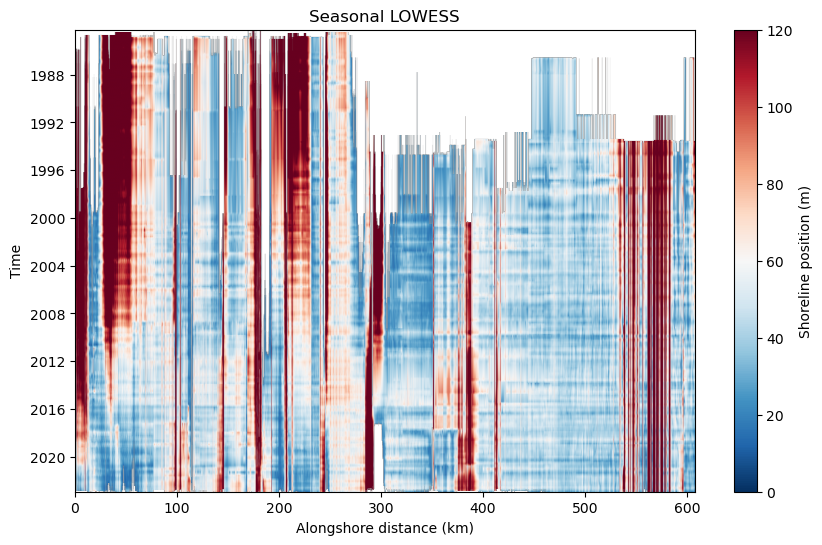

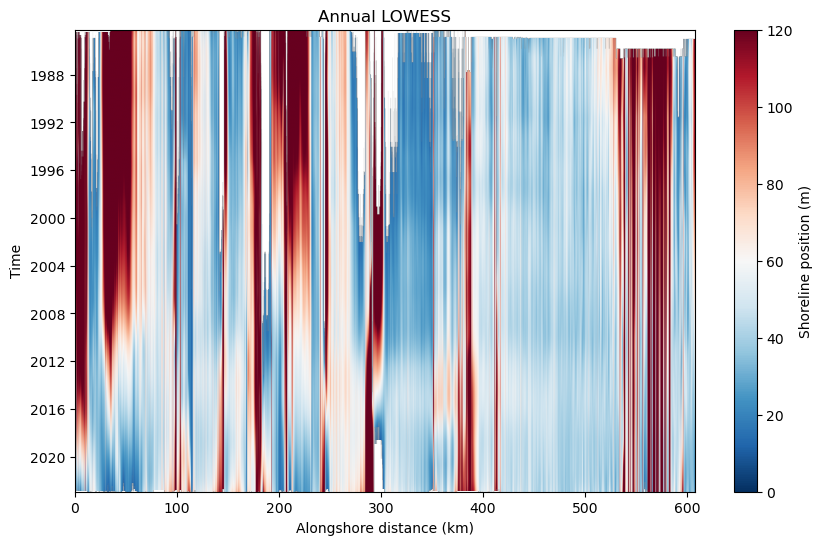

In [10]:
# Step 3: plot heatmaps
plot_heatmap(tgrid, s, M_seasonal, title="Seasonal LOWESS", vmin=0, vmax=120)
plot_heatmap(tgrid, s, M_annual, title="Annual LOWESS", vmin=0, vmax=120)

C:\Users\csherwood\AppData\Local\Temp\1\ipykernel_37964\3549732631.py:111: RuntimeWarning: Mean of empty slice
  mean_cycle = np.nanmean(Y, axis=0)
C:\Users\csherwood\AppData\Local\miniforge3\envs\CRS\lib\site-packages\numpy\lib\_nanfunctions_impl.py:2053: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


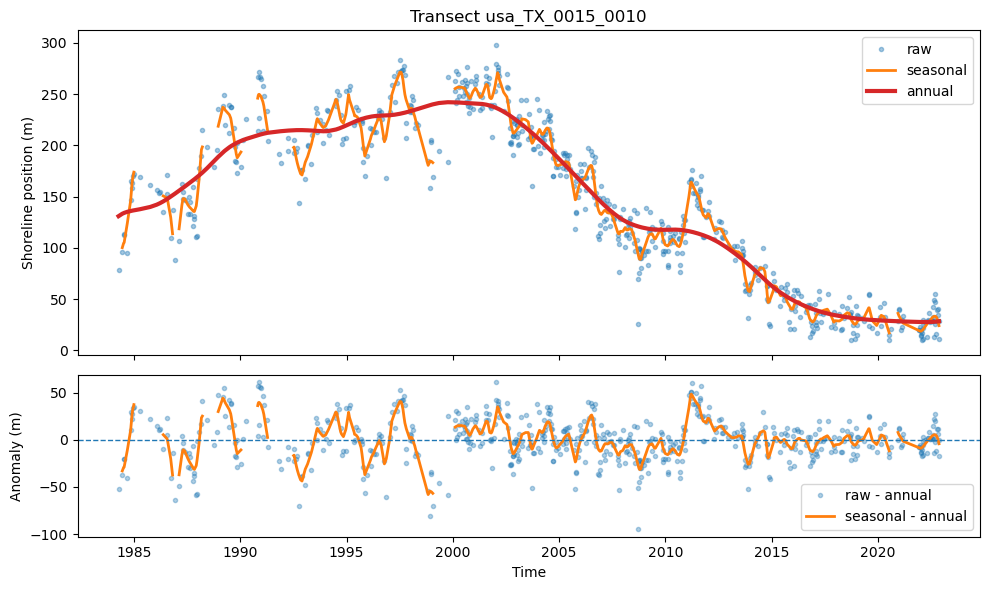

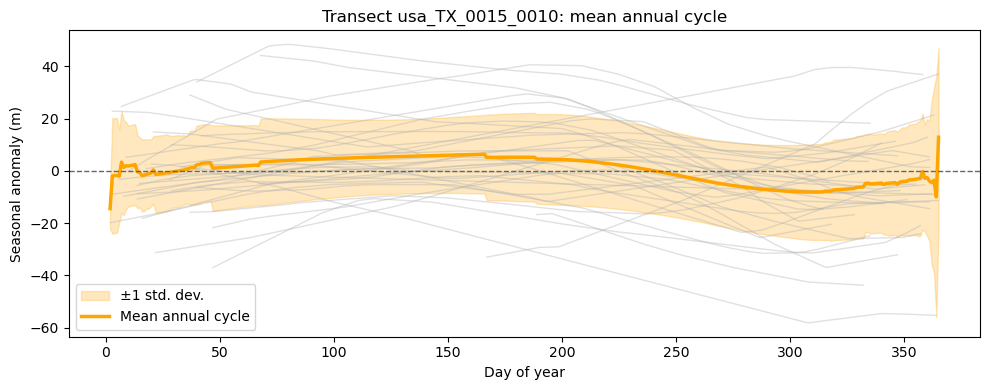

In [11]:
# Step 4: inspect specific transects
plot_dir = "F:/crs/proj/2026_shoreline_analysis/profiles_4yr_111dy/"
transect_id = "usa_TX_0015_0010"
fig, ax = plot_transect_timeseries_two_panel(df_loess, transect_id)
fig.savefig( plot_dir+transect_id+'.png', dpi=200 )

fig, ax, annual_cycle = plot_mean_annual_cycle(
    df_loess,
    transect_id,
    time_col="datetime",
    id_col="ID",
)

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def plot_transect_three_panel(
    df,
    transect_id,
    time_col="datetime",
    y_col="distance",
    id_col="ID",
    seasonal_col="y_seasonal",
    annual_col="y_annual",
    ndoy=366,
    min_points_per_year=6,
    min_years_per_doy=5,
    figsize=(10, 9),
):
    """
    Three-panel figure for one transect.

    Panel 1:
        raw shoreline, seasonal LOWESS, annual LOWESS

    Panel 2:
        seasonal anomaly = y_seasonal - y_annual
        Keeps NaNs, so natural breaks are preserved where the anomaly is NaN.

    Panel 3:
        stacked annual cycles:
        - each year in faint gray
        - mean annual cycle in orange
        - +/- 1 std. dev. shaded

    Notes
    -----
    The mean and std are set to NaN wherever fewer than min_years_per_doy
    yearly curves contribute.
    """

    g = df.copy()

    # enforce types
    g[id_col] = g[id_col].astype(str).str.strip()
    transect_id = str(transect_id).strip()

    g[time_col] = pd.to_datetime(g[time_col], errors="coerce")
    for col in [y_col, seasonal_col, annual_col]:
        g[col] = pd.to_numeric(g[col], errors="coerce")

    g = g[g[id_col] == transect_id].sort_values(time_col).copy()

    if len(g) == 0:
        raise ValueError(f"No rows found where {id_col} == {transect_id}")

    # Keep NaNs in seasonal/annual for plotting panels 1-2
    g_plot = g.dropna(subset=[time_col, y_col]).copy()

    if len(g_plot) == 0:
        raise ValueError("No valid rows remain after dropping NaNs in time/raw shoreline.")

    g_plot["seasonal_anomaly"] = g_plot[seasonal_col] - g_plot[annual_col]

    # Use only valid anomaly rows for annual-cycle stacking
    g_cycle = g_plot.dropna(subset=["seasonal_anomaly"]).copy()

    if len(g_cycle) == 0:
        raise ValueError("No valid seasonal anomaly values available for annual-cycle stacking.")

    g_cycle["year"] = g_cycle[time_col].dt.year
    g_cycle["doy"] = (
        g_cycle[time_col].dt.dayofyear
        + g_cycle[time_col].dt.hour / 24.0
        + g_cycle[time_col].dt.minute / 1440.0
        + g_cycle[time_col].dt.second / 86400.0
    )

    # common day-of-year grid
    doy_grid = np.linspace(1, 366, ndoy)

    curves = []
    years_used = []

    for yr, gy in g_cycle.groupby("year"):
        gy = gy.sort_values("doy").copy()

        x = gy["doy"].to_numpy(dtype=float)
        y = gy["seasonal_anomaly"].to_numpy(dtype=float)

        good = np.isfinite(x) & np.isfinite(y)
        x = x[good]
        y = y[good]

        if len(x) < min_points_per_year:
            continue

        # collapse duplicate doy values within a year if needed
        tmp = (
            pd.DataFrame({"doy": x, "y": y})
            .groupby("doy", as_index=False)
            .mean()
        )
        x = tmp["doy"].to_numpy(dtype=float)
        y = tmp["y"].to_numpy(dtype=float)

        if len(x) < 2:
            continue

        yi = np.interp(doy_grid, x, y, left=np.nan, right=np.nan)

        # retain only the portion inside the sampled range for that year
        inside = (doy_grid >= np.nanmin(x)) & (doy_grid <= np.nanmax(x))
        yi[~inside] = np.nan

        curves.append(yi)
        years_used.append(yr)

    if len(curves) == 0:
        raise ValueError("No years had enough valid points to build annual cycles.")

    Y = np.vstack(curves)

    n_contrib = np.sum(np.isfinite(Y), axis=0)
    mean_cycle = np.nanmean(Y, axis=0)
    std_cycle = (
        np.nanstd(Y, axis=0, ddof=1)
        if Y.shape[0] > 1
        else np.full(ndoy, np.nan)
    )

    # mask where too few years contribute
    bad = n_contrib < min_years_per_doy
    mean_cycle[bad] = np.nan
    std_cycle[bad] = np.nan

    # plotting
    fig, axs = plt.subplots(
        3, 1,
        figsize=figsize,
        sharex=False,
        gridspec_kw={"height_ratios": [2.0, 1.2, 1.4]}
    )

    # panel 1: raw + LOWESS
    axs[0].plot(g_plot[time_col], g_plot[y_col], ".", label="raw", alpha=0.35)
    axs[0].plot(g_plot[time_col], g_plot[annual_col], "-",c="tab:red", alpha=0.8, lw=3, label="annual")
    axs[0].plot(g_plot[time_col], g_plot[seasonal_col], "-", c="tab:orange", lw=2, label="seasonal")
    axs[0].set_ylabel("Shoreline position (m)")
    axs[0].set_title(f"Transect {transect_id}")
    axs[0].legend()

    # panel 2: anomaly time series
    axs[1].plot(g_plot[time_col], g_plot["seasonal_anomaly"], "-", c="tab:orange", lw=1.8)
    axs[1].axhline(0.0, ls="--", lw=1)
    axs[1].set_xlabel("Time")
    axs[1].set_ylabel("Seasonal\nanomaly (m)")

    # panel 3: stacked annual cycles
    for i in range(Y.shape[0]):
        axs[2].plot(doy_grid, Y[i, :], "-", color="0.7", alpha=0.35, lw=1)

    axs[2].fill_between(
        doy_grid,
        mean_cycle - std_cycle,
        mean_cycle + std_cycle,
        color="orange",
        alpha=0.25,
        label="±1 std. dev."
    )

    axs[2].plot(
        doy_grid,
        mean_cycle,
        "-",
        color="orange",
        lw=2.5,
        label="Mean annual cycle"
    )

    axs[2].axhline(0.0, color="0.4", ls="--", lw=1)
    axs[2].set_xlabel("Day of year")
    axs[2].set_ylabel("Cycle (m)")
    axs[2].set_title("Stacked annual cycles")
    axs[2].legend()

    fig.tight_layout()

    outdict = {
        "transect_id": transect_id,
        "time_series_plot": g_plot.copy(),
        "time_series_cycle": g_cycle.copy(),
        "doy_grid": doy_grid,
        "annual_curves": Y,
        "years_used": np.array(years_used),
        "n_contrib": n_contrib,
        "mean_cycle": mean_cycle,
        "std_cycle": std_cycle,
    }

    return fig, axs, outdict

C:\Users\csherwood\AppData\Local\Temp\1\ipykernel_37964\3885804585.py:123: RuntimeWarning: Mean of empty slice
  mean_cycle = np.nanmean(Y, axis=0)
C:\Users\csherwood\AppData\Local\miniforge3\envs\CRS\lib\site-packages\numpy\lib\_nanfunctions_impl.py:2053: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


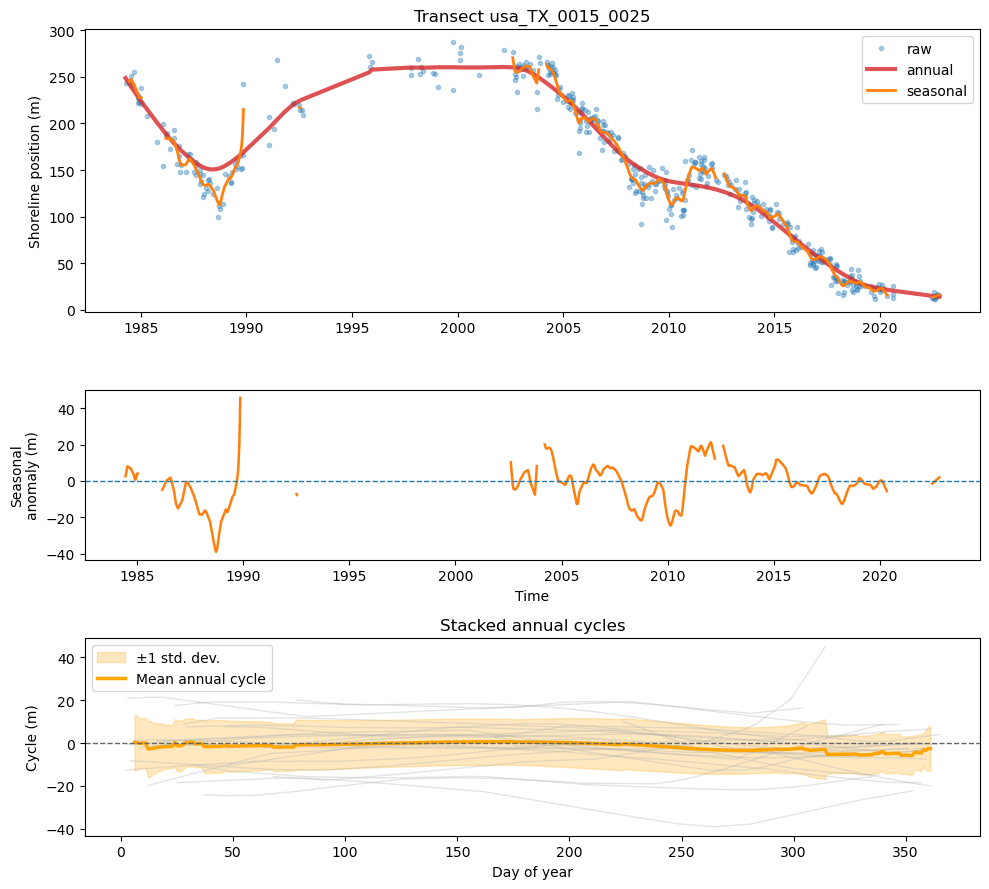

In [13]:
plot_dir = "F:/crs/proj/2026_shoreline_analysis/profiles/"
transect_id = "usa_TX_0015_0025"
fig, axs, out = plot_transect_three_panel(
    df_loess,
    transect_id,
    time_col="datetime",
    y_col="distance",
    id_col="ID",
    min_points_per_year=6,
    min_years_per_doy=5,
)
fig.savefig( plot_dir+transect_id+'seasonal.png', dpi=200 )

In [14]:
shoreline_df["ID"]

0          usa_TX_0001_0001
1          usa_TX_0001_0001
2          usa_TX_0001_0001
3          usa_TX_0001_0001
4          usa_TX_0001_0001
                 ...       
4804388    usa_TX_0033_0246
4804389    usa_TX_0033_0246
4804390    usa_TX_0033_0246
4804391    usa_TX_0033_0246
4804392    usa_TX_0033_0246
Name: ID, Length: 4804393, dtype: object

In [15]:
ids = df_loess["ID"].dropna().unique()
sample_ids = np.random.choice(ids, size=100, replace=False)
print(sample_ids)

['usa_TX_0007_0325' 'usa_TX_0033_0126' 'usa_TX_0008_0463'
 'usa_TX_0004_0280' 'usa_TX_0030_0039' 'usa_TX_0023_0419'
 'usa_TX_0002_0201' 'usa_TX_0029_0099' 'usa_TX_0021_0196'
 'usa_TX_0019_0159' 'usa_TX_0002_0229' 'usa_TX_0018_0224'
 'usa_TX_0003_0206' 'usa_TX_0008_0237' 'usa_TX_0032_0293'
 'usa_TX_0030_0149' 'usa_TX_0032_0575' 'usa_TX_0001_0240'
 'usa_TX_0007_0011' 'usa_TX_0032_0236' 'usa_TX_0022_0122'
 'usa_TX_0033_0199' 'usa_TX_0027_0165' 'usa_TX_0013_0251'
 'usa_TX_0008_0204' 'usa_TX_0025_0099' 'usa_TX_0012_0003'
 'usa_TX_0001_0188' 'usa_TX_0020_0535' 'usa_TX_0023_0192'
 'usa_TX_0033_0083' 'usa_TX_0031_0396' 'usa_TX_0029_0087'
 'usa_TX_0022_0098' 'usa_TX_0001_0095' 'usa_TX_0023_0206'
 'usa_TX_0014_0183' 'usa_TX_0027_0067' 'usa_TX_0025_0405'
 'usa_TX_0030_0061' 'usa_TX_0021_0042' 'usa_TX_0023_0251'
 'usa_TX_0029_0039' 'usa_TX_0018_0205' 'usa_TX_0020_0162'
 'usa_TX_0003_0025' 'usa_TX_0011_0027' 'usa_TX_0019_0212'
 'usa_TX_0003_0288' 'usa_TX_0027_0086' 'usa_TX_0016_0017'
 'usa_TX_0022_

In [16]:
for transect_id in sample_ids:
    fig, axs, out = plot_transect_three_panel(
        df_loess,
        transect_id,
        time_col="datetime",
        y_col="distance",
        id_col="ID",
        min_points_per_year=6,
        min_years_per_doy=5,
    )
    fig.savefig( plot_dir+transect_id+'seasonal.png', dpi=200 )

ValueError: No years had enough valid points to build annual cycles.

In [ ]:
random_integers = [np.random.randint(1, 1216) for _ in range(len( np.unique( shoreline_df["ID"].values ) ))]

In [ ]:
print(len(random_integers))

In [ ]:
for i in random_integers:
    print( np.unique( shoreline_df["ID"].values )[i] )